# 02 — Distributions and Missingness

**Chapter 4 companion.** Institutional data is dominated by scale. A few very large
institutions set the mean, count outcomes are overdispersed, and a missing value
usually means "not asked" rather than "not answered". Each section makes one of
these properties measurable before any model sees the data.

| | |
|---|---|
| Input | `data/analytic/institutions_2023.parquet` (from notebook 01), `data/curated/c05_c` |
| Methods | Log-normal fit with QQ diagnostics, robust location and scale, Poisson vs negative-binomial GLMs, definitional ratios, structural vs non-response missingness |

In [1]:
import os
import sys
import warnings
from pathlib import Path

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ipeds_utils as iu

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({
    "figure.dpi": 100, "figure.figsize": (8, 4.2),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "font.size": 10,
})

ANALYTIC = Path("../data/analytic")
FIGURES = Path("../reports/figures")
ANALYTIC.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

SEED = 20231  # one seed for every stochastic step, so reruns reproduce exactly
rng = np.random.default_rng(SEED)


def save(name):
    """Save the current figure to reports/figures and display it."""
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"ipeds_utils {iu.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

ipeds_utils 1.1.0 | pandas 3.0.5 | numpy 2.5.3


In [2]:
source = ANALYTIC / "institutions_2023.parquet"
if not source.exists():
    raise FileNotFoundError("Run 01_ingest_clean_deidentify.ipynb first; it builds the analytic table.")

inst = pd.read_parquet(source)
inst = inst[inst["IN_UNIVERSE"]].copy()
print(f"{len(inst):,} institutions in the analysis universe")

5,988 institutions in the analysis universe


## 1. Heavy tails: tuition revenue

Revenue spans five orders of magnitude, so the mean describes almost no one. On a
log scale the distribution is close to normal, which is what licenses modelling log
revenue in notebook 07. The check below does not use a normality test, because with
thousands of rows any test rejects a trivially small deviation. It compares tail
mass instead: the share of log values beyond three standard deviations, against the
0.27% a normal distribution predicts.

In [3]:
from scipy import stats

rev = inst.loc[inst["TUITION_REVENUE"] > 0, "TUITION_REVENUE"]
log_rev = np.log10(rev)
print(f"{len(rev):,} institutions with positive tuition revenue "
      f"({(inst['TUITION_REVENUE'] <= 0).sum():,} zero or negative, {inst['TUITION_REVENUE'].isna().sum():,} not reported)")

z = (log_rev - log_rev.mean()) / log_rev.std()
pd.DataFrame({
    "dollars": [rev.mean(), rev.median(), stats.skew(rev), np.nan],
    "log10 dollars": [log_rev.mean(), log_rev.median(), stats.skew(log_rev), (z.abs() > 3).mean()],
}, index=["mean", "median", "skewness", "share beyond 3 SD"])

5,683 institutions with positive tuition revenue (18 zero or negative, 287 not reported)


,dollars,log10 dollars
mean,"32,770,548.389",6.678
median,"4,444,859.000",6.648
skewness,8.849,0.062
share beyond 3 SD,NaN,0.004


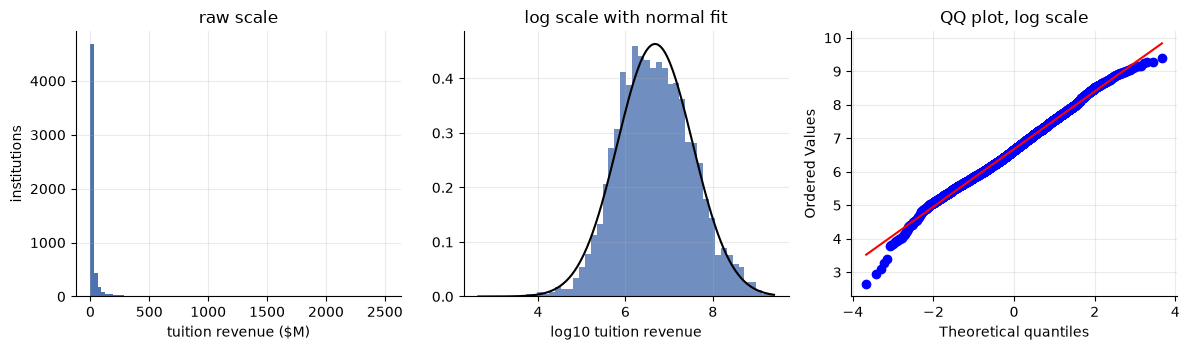

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].hist(rev / 1e6, bins=80, color="#4C72B0")
axes[0].set(xlabel="tuition revenue ($M)", ylabel="institutions", title="raw scale")
axes[1].hist(log_rev, bins=50, density=True, color="#4C72B0", alpha=0.8)
grid = np.linspace(log_rev.min(), log_rev.max(), 200)
axes[1].plot(grid, stats.norm.pdf(grid, log_rev.mean(), log_rev.std()), color="k")
axes[1].set(xlabel="log10 tuition revenue", title="log scale with normal fit")
stats.probplot(log_rev, dist="norm", plot=axes[2])
axes[2].set_title("QQ plot, log scale")
save("02_tuition_lognormal")

The log scale removes almost all the skew, but the tails are asymmetric: the QQ
plot bends at the lower end, where more institutions fall below -3 SD than above +3.
The next cell lists them. They are very small less-than-two-year schools, plus
institutions that are funded mainly through appropriations and charge little or no
tuition. Public (GASB) tuition is also reported after deducting discounts and
allowances, as the `F1B01` label says, so a public that covers most tuition through
allowances reports almost none. For all of these institutions tuition revenue is a
poor proxy for scale, so a model of log revenue (notebook 07) should be checked for
residuals concentrated there.

In [5]:
tails = inst.loc[rev.index].assign(z=(log_rev - log_rev.mean()) / log_rev.std())
print(f"below -3 SD: {(tails['z'] < -3).sum()}   above +3 SD: {(tails['z'] > 3).sum()}")
(tails[tails["z"] < -3].sort_values("z")
     [["INSTNM", "SECTOR_LABEL", "TUITION_REVENUE", "TOTAL_REVENUES", "ENROLL_FALL"]].head(10))

below -3 SD: 17   above +3 SD: 3


,INSTNM,SECTOR_LABEL,TUITION_REVENUE,TOTAL_REVENUES,ENROLL_FALL
4575,John D Rockefeller IV Career Center,"Public, less-than 2-year",430.000,"481,206.000",14.000
5781,Red Lake Nation College,"Public, 2-year",855.000,"4,949,883.000",256.000
4497,Cambridge Technical Institute,"Private for-profit, less-than 2-year","1,285.000","51,287.000",27.000
26,J F Ingram State Technical College,"Public, less-than 2-year","1,851.000","30,962,623.000",826.000
4456,Colegio Educativo Tecnologico Industrial Inc,"Private not-for-profit, less-than 2-year","2,500.000","272,173.000",75.000
5674,Gadsden Technical College,"Public, less-than 2-year","6,000.000","382,000.000",114.000
5283,Paul Mitchell the School-Woodbridge,"Private for-profit, less-than 2-year","6,584.000","30,074.000",NaN
3768,New College of Florida,"Public, 4-year or above","7,069.000","62,939,544.000",732.000
1605,Michigan Career and Technical Institute,"Public, less-than 2-year","8,060.000","13,167,935.000",118.000
6093,Renaissance Beauty Academy,"Private for-profit, less-than 2-year","8,500.000","646,000.000",68.000


## 2. Robust location and scale: student-to-faculty ratio

A handful of institutions report very high student-to-faculty ratios, mostly large
online providers and small programs with few instructional staff. The comparison
below removes the top 1% and asks which summaries move. The median and the scaled
MAD (which estimates the SD under normality) barely change; the mean and SD do.

In [6]:
x = inst["STUFACR"].dropna()


def summarize(s):
    return pd.Series({
        "n": len(s), "mean": s.mean(), "SD": s.std(), "median": s.median(),
        "MAD (normal-scaled)": stats.median_abs_deviation(s, scale="normal"),
        "IQR": s.quantile(0.75) - s.quantile(0.25),
    })


trimmed = x[x <= x.quantile(0.99)]
robust = pd.DataFrame({"all": summarize(x), "top 1% removed": summarize(trimmed)})
robust["relative change"] = robust["top 1% removed"] / robust["all"] - 1
robust

,all,top 1% removed,relative change
n,"5,645.000","5,604.000",-0.007
mean,15.282,14.999,-0.019
SD,7.568,6.421,-0.152
median,14.000,14.000,0.000
MAD (normal-scaled),5.930,5.930,0.000
IQR,9.000,9.000,0.000


In [7]:
inst.nlargest(6, "STUFACR")[["INSTNM", "SECTOR_LABEL", "STUFACR", "ENROLL_FALL", "PCTE12DEEXC"]]

,INSTNM,SECTOR_LABEL,STUFACR,ENROLL_FALL,PCTE12DEEXC
4416,Caribbean Forensic and Technical College,"Private for-profit, less-than 2-year",191.000,381.000,0.000
5446,University of Phoenix-Arizona,"Private for-profit, 4-year or above",132.000,"101,150.000",100.000
5084,Meridian Institute of Surgical Assisting,"Private for-profit, 2-year",87.000,788.000,4.000
2730,American College of Financial Services,"Private not-for-profit, 4-year or above",83.000,"4,204.000",98.000
5593,Martinsburg College,"Private for-profit, 4-year or above",73.000,"3,228.000",100.000
3832,Ross Medical Education Center-Taylor,"Private for-profit, less-than 2-year",57.000,57.000,0.000


## 3. Count outcomes are overdispersed

Awards conferred are counts. The Poisson model assumes variance equal to the mean;
institutional counts violate that badly, because institutions of the same size
differ in program mix and completion. Before fitting, the count has to be built
correctly. Completions files contain a CIP `99` row that is the grand total for each
award level, plus detail rows for each program and a second-major block. Summing
every row counts each award more than twice.

In [8]:
comp, _ = iu.read_curated("c05_c", root="../data/curated")
first = comp["MAJORNUM"] == 1
pd.Series({
    "every row": comp["CTOTALT"].sum(),
    "first-major detail rows (CIP != 99)": comp.loc[first & (comp["CIPCODE"] != "99"), "CTOTALT"].sum(),
    "first-major CIP 99 totals": comp.loc[first & (comp["CIPCODE"] == "99"), "CTOTALT"].sum(),
    "AWARDS_TOTAL in the analytic table": inst["AWARDS_TOTAL"].sum(),
}).map("{:,.0f}".format).to_frame("awards")

,awards
every row,"10,798,636"
first-major detail rows (CIP != 99),"5,299,203"
first-major CIP 99 totals,"5,299,203"
AWARDS_TOTAL in the analytic table,"5,299,203"


The two first-major totals agree exactly, which is what the `rolls_up` rule in
`c05_c` enforces. Summing every row roughly doubles the count.

With the count settled, the models below regress awards on log fall enrollment. The
Pearson dispersion statistic (chi-square / residual df) should be near 1 for a
Poisson model that fits.

In [9]:
import statsmodels.api as sm

counts = inst.dropna(subset=["AWARDS_TOTAL", "ENROLL_FALL"]).query("ENROLL_FALL > 0")
y = counts["AWARDS_TOTAL"].to_numpy(dtype=float)
X = sm.add_constant(np.log(counts["ENROLL_FALL"].to_numpy(dtype=float)))

poisson = sm.GLM(y, X, family=sm.families.Poisson()).fit()
negbin = sm.NegativeBinomial(y, X).fit(disp=False)

pd.DataFrame({
    "Poisson": [poisson.aic, poisson.pearson_chi2 / poisson.df_resid, poisson.params[1], np.nan],
    "negative binomial (NB2)": [negbin.aic, np.nan, negbin.params[1], negbin.params[-1]],
}, index=["AIC", "Pearson dispersion", "elasticity on log enrollment", "alpha (overdispersion)"])

,Poisson,negative binomial (NB2)
AIC,"816,596.244","75,759.637"
Pearson dispersion,159.517,NaN
elasticity on log enrollment,0.914,0.769
alpha (overdispersion),NaN,0.368


A dispersion statistic far above 1 means Poisson standard errors are too small by
roughly its square root, so every significance test built on them overstates
certainty. The negative binomial absorbs the extra variance through `alpha`, and its
far lower AIC confirms the better fit.

The two models also disagree on the elasticity itself. Because Poisson assumes
variance equals the mean, the largest institutions dominate its fit. The negative
binomial down-weights them and finds a smaller elasticity, meaning awards grow less
than proportionally with fall headcount. (Why that happens is a hypothesis for
exercise 1, not a finding here.) A misspecified variance function changes the
substantive answer, not just the standard errors.

## 4. Enrollment is a definition, not a number

Fall headcount and 12-month unduplicated headcount measure different populations.
Their ratio is large where students enroll for short programs or start outside the
fall term. The two windows also do not line up: `DRVEF122023` covers July 1, 2022 to
June 30, 2023, while fall 2023 comes after that window closes. A ratio below 1
therefore usually means growth between the two periods, not a data error.

In [10]:
ratio = inst.dropna(subset=["TWELVE_TO_FALL"])
summary = (ratio.groupby("SECTOR_LABEL")["TWELVE_TO_FALL"]
                .agg(institutions="size", median="median", share_below_1=lambda s: (s < 1).mean())
                .sort_values("median", ascending=False))
print(f"{(ratio['TWELVE_TO_FALL'] < 1).sum():,} institutions report more fall 2023 students than 2022-23 unduplicated students")
summary

368 institutions report more fall 2023 students than 2022-23 unduplicated students


,institutions,median,share_below_1
SECTOR_LABEL,,,
"Private for-profit, less-than 2-year",1372,1.636,0.039
"Private for-profit, 2-year",514,1.547,0.049
"Private not-for-profit, less-than 2-year",56,1.417,0.125
"Private for-profit, 4-year or above",319,1.410,0.103
"Public, 2-year",868,1.363,0.026
"Public, less-than 2-year",226,1.358,0.195
"Private not-for-profit, 2-year",127,1.279,0.110
"Public, 4-year or above",820,1.185,0.020
"Private not-for-profit, 4-year or above",1607,1.157,0.095


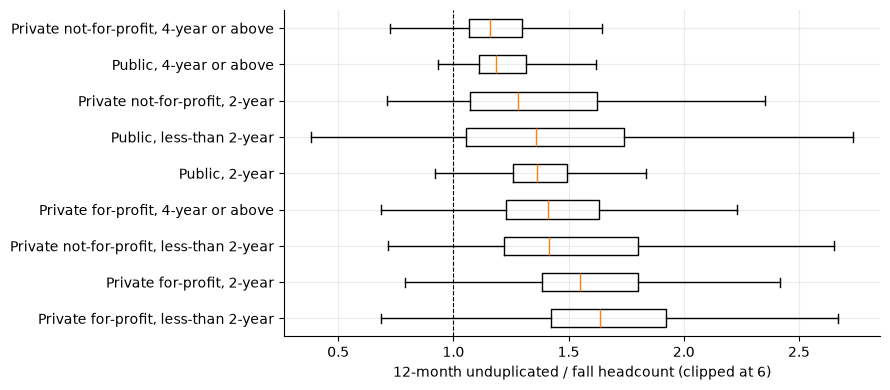

In [11]:
order = summary.index.tolist()
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([ratio.loc[ratio["SECTOR_LABEL"] == s, "TWELVE_TO_FALL"].clip(upper=6) for s in order],
           orientation="horizontal", showfliers=False)
ax.set_yticks(range(1, len(order) + 1), order)
ax.axvline(1, color="k", lw=0.8, ls="--")
ax.set(xlabel="12-month unduplicated / fall headcount (clipped at 6)")
save("02_twelve_to_fall")

## 5. Missing by design versus missing by non-response

Missingness in IPEDS is mostly structural: a survey item is not collected from an
institution type, or an upstream screening question routes the institution past it.
Treating structural gaps as random non-response, and imputing them, invents data for
institutions that were never asked.

In [12]:
cols = ["RET_PCF", "BA_RATE_150", "L4_RATE_150", "ADMIT_RATE", "OM1TOTLAWDP8",
        "TUITION_SHARE", "TENURE_DENSITY", "LEXPTOTF"]
missing = inst.groupby("SECTOR_LABEL")[cols].apply(lambda d: d.isna().mean())
missing.map("{:.0%}".format)

,RET_PCF,BA_RATE_150,L4_RATE_150,ADMIT_RATE,OM1TOTLAWDP8,TUITION_SHARE,TENURE_DENSITY,LEXPTOTF
SECTOR_LABEL,,,,,,,,
"Private for-profit, 2-year",4%,100%,8%,89%,34%,9%,48%,96%
"Private for-profit, 4-year or above",45%,56%,100%,72%,30%,17%,34%,71%
"Private for-profit, less-than 2-year",13%,100%,9%,98%,100%,5%,100%,100%
"Private not-for-profit, 2-year",22%,100%,22%,60%,44%,5%,64%,91%
"Private not-for-profit, 4-year or above",24%,26%,100%,32%,21%,4%,14%,25%
"Private not-for-profit, less-than 2-year",27%,100%,15%,81%,100%,5%,100%,100%
"Public, 2-year",0%,100%,1%,98%,9%,1%,9%,16%
"Public, 4-year or above",21%,25%,100%,34%,5%,4%,2%,7%
"Public, less-than 2-year",10%,100%,8%,81%,100%,3%,100%,100%


The pattern is sectoral, and most of it is structural. Graduation-rate measures
split cleanly by level: the bachelor's-cohort rate is 100% missing outside four-year
institutions and the less-than-four-year rate is 100% missing inside them. Outcome
Measures and tenure status are absent for every less-than-two-year institution.
Admissions data covers only institutions without open admission, so its gaps mark a
policy rather than a failure to report. The library block shows both kinds of
missingness at once.

In [13]:
library = inst.assign(
    screening=inst["LEXP100K"].map({1: "1: expenditures >= $100K (detail collected)",
                                    2: "2: expenditures < $100K (detail skipped)"})
                              .fillna(pd.Series(np.where(inst["LIB_FROM_PARENT"],
                                                         "no own report (parent value removed)",
                                                         "no Academic Libraries report"),
                                                index=inst.index)),
)
pd.crosstab(library["screening"], library["LEXPTOTF"].isna().map({False: "present", True: "missing"}))

LEXPTOTF,missing,present
screening,,
1: expenditures >= $100K (detail collected),0,2829
2: expenditures < $100K (detail skipped),866,0
no Academic Libraries report,2020,0
no own report (parent value removed),273,0


Every institution that answered `LEXP100K = 2` is missing the expenditure detail,
and every institution that answered 1 has it. The gap is structural, so the correct
treatment is a category ("small library") rather than an imputed dollar figure.
Notebook 05 handles the library block this way.

## Exercises

1. Fit the negative binomial with an additional `CONTROL` term. Does `alpha` fall,
   and what does that say about where the overdispersion comes from?
2. For institutions with a 12-month/fall ratio below 0.8, compare fall 2022
   headcount (`EF2022A`) with fall 2023. Is growth the explanation?
3. Plot `STUFACR` against `PCTE12DEEXC` (share exclusively online). How much of the
   upper tail does online delivery explain?